<a href="https://colab.research.google.com/github/CB-Mechatronics/CB-Mechatronics/blob/main/MotorAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




**IoT Condition Monitoring System Using Explainable Artificial Intelligence for Induction Motors**

*Sistema IoT de monitoreo de condición aplicando inteligencia artificial explicable para motores de inducción*

In [67]:
#===Libraries===

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn import svm
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

#Initial values
rng=np.random.default_rng(seed=42)
sample=200


The program begins by generating RNG data with the aim of simulating data obtained from real sensors. The thresholds for identifying faults were derived from ISO standards for vibration-related engine faults and IEEE standards for current monitoring in electric motors.

*El programa comienza con la creacion de datos rng con el obejtivo de recrear datos obtenidos por sensores reales. Los rangos para determinar las fallas fueron obtenidos por medio de la Normativa ISO para fallas con vibración en motores y normas IEEE para revisión de corriente en motores eléctricos.*

![Tabla ISO 10816-3](https://raw.githubusercontent.com/CB-Mechatronics/motor-predictive-maintenance-iot/refs/heads/main/Docs/ISO%2018016.jfif)

**Figure 1: ISO 10816-3 Vibration failure table**


In [68]:
#Motor States
#========================
#===  Healthy Motor   ===
#========================

norm_vib=rng.normal(loc=0.8, scale=0.01, size=sample)
norm_curr=rng.normal(loc=0.05, scale=0.01,size=sample)
norm_temp=rng.normal(loc=40, scale=2,size=sample)
norm_class=np.zeros(sample)






In [69]:

#===========================
#=== Mechanical Failure  ===
#===========================

#According to ISO Norm 10816
mech_vib=rng.normal(loc=4.5,scale=0.5,size=sample)
mech_curr=rng.normal(loc=0.06,scale=0.01,size=sample)
mech_temp=rng.normal(loc=40,scale=2,size=sample)
mech_class=np.ones(sample)

#===========================
#=== Electrical Failure  ===
#===========================

#According to IEEE
electr_vib=rng.normal(loc=0.9,scale=0.5,size=sample)
electr_curr=rng.normal(loc=1.25,scale=0.1,size=sample)
electr_temp=rng.normal(loc=68,scale=4,size=sample)
electr_class=np.ones(sample)*2








The concatanate function from numpy is use to create a dataframe that contains information for RMS Vibration, *MCSA* current, temperature and the respective motor state associated for each one. A Scatterplot is created using Seaborn to help the user to visualize the dispersion of the data.

In [70]:
#Data concatanation
tot_vib=np.concatenate((norm_vib,mech_vib,electr_vib))
tot_curr=np.concatenate((norm_curr,mech_curr,electr_curr))
tot_temp=np.concatenate((norm_temp,mech_temp,electr_temp))
tot_class=np.concatenate((norm_class,mech_class,electr_class))


#Feature Fusion
dataframe=pd.DataFrame({"RMS_Vibration":tot_vib,
                       "MCSA Current":tot_curr,
                        "Temperature":tot_temp,
                        "Motor State":tot_class
                       })
dataframe.head()
print("\nCantidad de muestras por estado del motor:")
print(dataframe["Motor State"].value_counts())


Cantidad de muestras por estado del motor:
Motor State
0.0    200
1.0    200
2.0    200
Name: count, dtype: int64


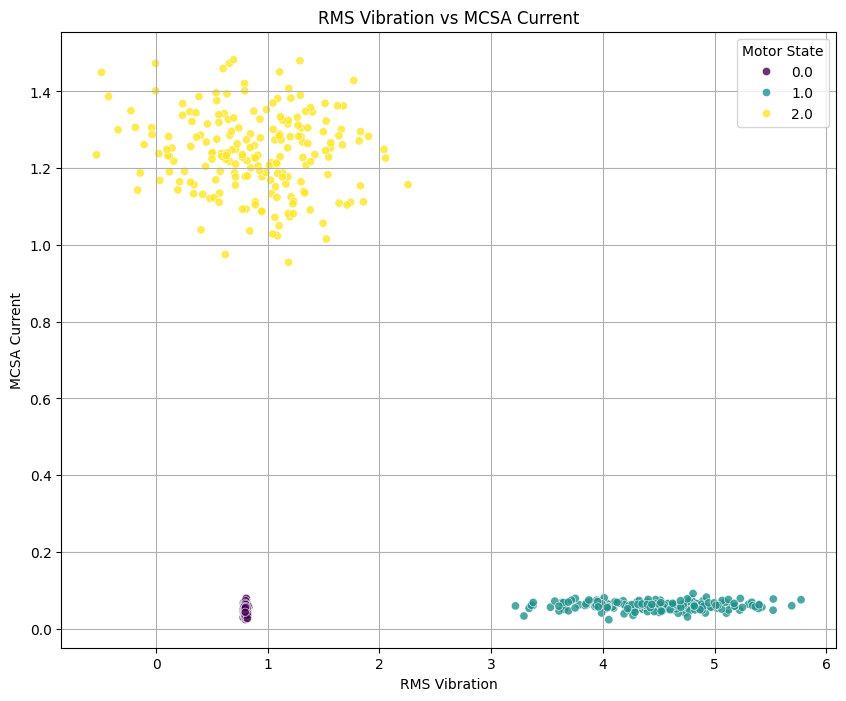

In [71]:
#Data Plot
plt.figure(figsize=(10,8))
sns.scatterplot(dataframe,x="RMS_Vibration",y="MCSA Current",hue="Motor State",palette="viridis",alpha=0.8)
plt.title("RMS Vibration vs MCSA Current")
plt.xlabel("RMS Vibration")
plt.ylabel("MCSA Current")
plt.grid(True)
plt.show()

In [72]:
#AI Training
X=dataframe.drop(columns=["Motor State"])
y=dataframe["Motor State"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In first place a Random Forest Model is applied to detect Healthy motor, Mechanical failure or Electrical Failure. The model achieves a impressive 100% accuracy, this is explained because the data generated for the model relies on standard values that are very predictable and is really easy for the algorithm to predict the results.

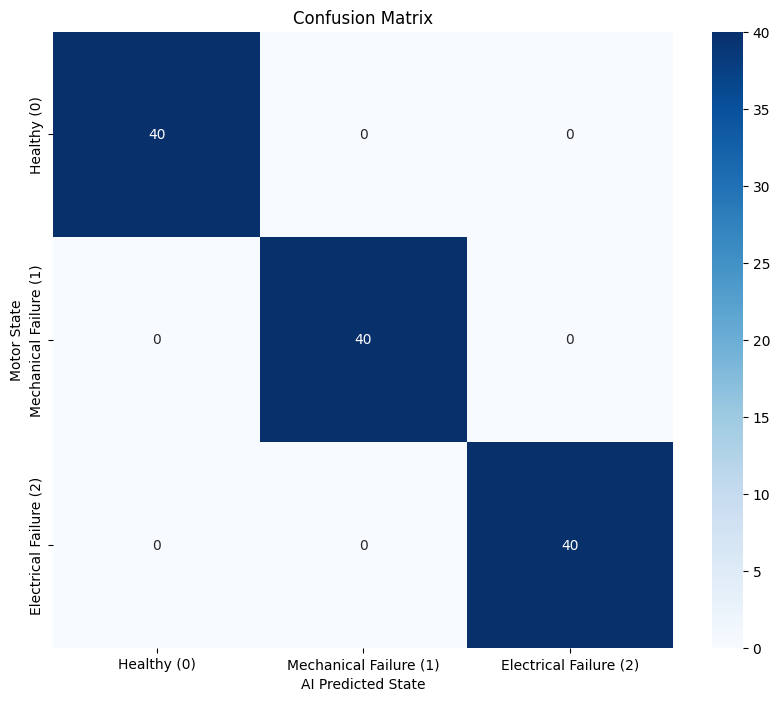

MODEL PERFORMANCE METRICS
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        40
         1.0       1.00      1.00      1.00        40
         2.0       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [73]:
#===============================
#===== Random Forest Model  ====#
#===============================

rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
predictions=rf_model.predict(X_test)

#Matriz de confusión
matrix=confusion_matrix(y_test,predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',xticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"],yticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"])
plt.title("Confusion Matrix")
plt.xlabel("AI Predicted State")
plt.ylabel("Motor State")
plt.show()

print("MODEL PERFORMANCE METRICS")
print(classification_report(y_test,predictions))

*SHapley Additive exPlanations* is a method that helps us understand how a machine learning model makes decisions. In this case we can visualize the behaviour of the metrics and how much they influence on the final answer of the model. With the help of a Beeswarm plot we can analize the situation of how the AI interprets the data from Electrical failure (Class 2). In this case the model concludes that MCSA current and temperature are the most important metrics to determinate this type of failure.

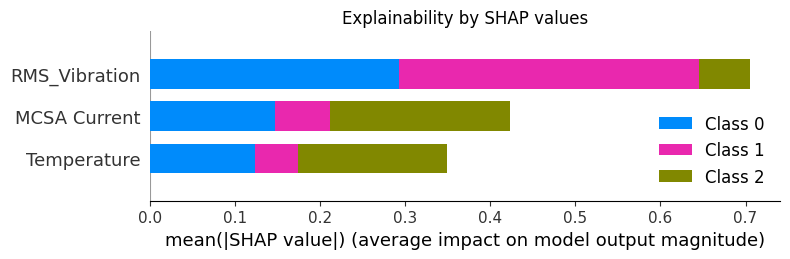

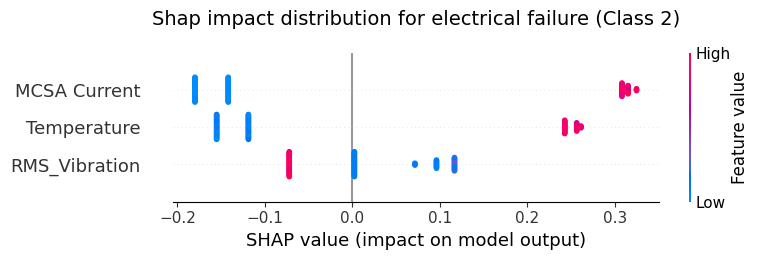

Indexes for Motor electrical failure in y_test:
[422, 461, 447, 580, 526]


<Figure size 1200x400 with 0 Axes>

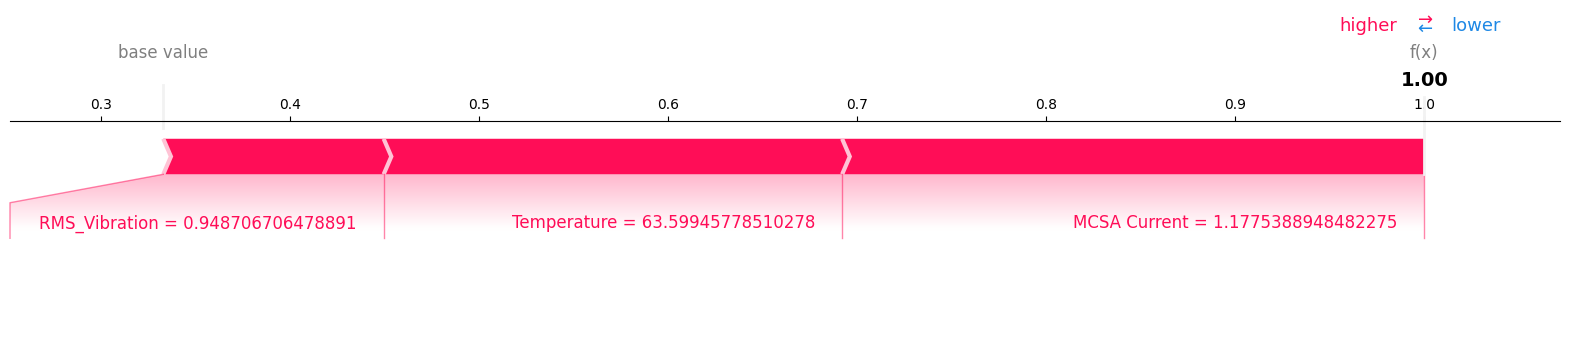

In [74]:
#Shap Explanation for Random Forest Model


#SHAP General Overview
shap_explainer=shap.TreeExplainer(rf_model)
shap_values=shap_explainer.shap_values(X_test)
plt.figure(figsize=(6,4))
plt.title("Explainability by SHAP values")
shap.summary_plot(shap_values,X_test,plot_type="bar",show=False)
plt.tight_layout()
plt.show()



#SHAP Beeswarm Plot

obj_electric_explainer = shap.Explanation(
    values=shap_values[:, :, 2],
    data=X_test,
    feature_names=X_test.columns
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(obj_electric_explainer, max_display=3, show=False)
plt.title("Shap impact distribution for electrical failure (Class 2)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


#SHAP Force Plot

#Index searching for an electric failure case
index_electric_fail = y_test[y_test == 2].index
print("Indexes for Motor electrical failure in y_test:")
print(list(index_electric_fail)[:5])



shap.initjs()


chosen_index = index_electric_fail[1]

position_in_test = X_test.index.get_loc(chosen_index)

obj_Ele_fail = shap.Explanation(
    values=shap_values[position_in_test, :, 2],
    base_values=shap_explainer.expected_value[2],
    data=X_test.iloc[position_in_test],
    feature_names=X_test.columns
)

# Force Plot Creation
plt.figure(figsize=(12, 4))
shap.plots.force(obj_Ele_fail, matplotlib=True)

Implementing Shapley Additive exPlanations (SHAP) in the *XGBoost* model is pretty straightforward because, like Random Forest, it is an ensemble method based on decision trees. Consequently, we can utilize the same "TreeExplainer" function to interpret the model's predictions.

The primary difference in the performance of these two algorithms lies in their classification accuracy. In this implementation, the *XGBoost* model misclassifies one instance, identifying a mechanical failure as a healthy motor. This behavior occurs because *XGBoost* trains trees sequentially to correct previous errors. While this sequential boosting process results in a significantly faster model, it can occasionally be more susceptible to localized classification errors compared to parallel architectures like *Random Forest*.

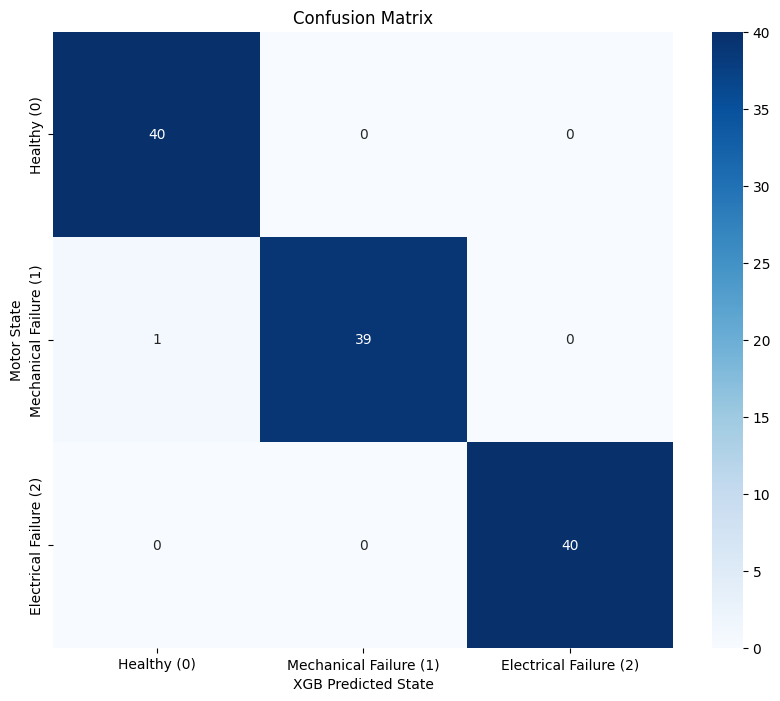

MODEL PERFORMANCE METRICS
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        40
         1.0       1.00      0.97      0.99        40
         2.0       1.00      1.00      1.00        40

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [75]:
#===============================
#===== XGBoost AI Model     ====
#===============================

model_xgb=XGBClassifier(n_estimators=100, random_state=42)
model_xgb.fit(X_train,y_train)
predictions_xgb=model_xgb.predict(X_test)
matrix=confusion_matrix(y_test,predictions_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',xticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"],yticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"])
plt.title("Confusion Matrix")
plt.xlabel("XGB Predicted State")
plt.ylabel("Motor State")
plt.show()

print("MODEL PERFORMANCE METRICS")
print(classification_report(y_test,predictions_xgb))


Key differences can be observed between the SHAP beeswarm and force plots for XGBoost and Random Forest. In the first place, the RF model is more reliable because it tries to give the same importance to RMS_Vibration, MCSA Current, and Temperature. For this reason, in the importance plot, we can visualize a more balanced feature distribution between the importance of each variable.

On the other hand, XGBoost detects that RMS_Vibration is mostly irrelevant to detect an Electrical Failure (Class 2), so the model assigns a disproportionately low value to it and focuses more on MCSA Current and Temperature to detect this kind of failure.

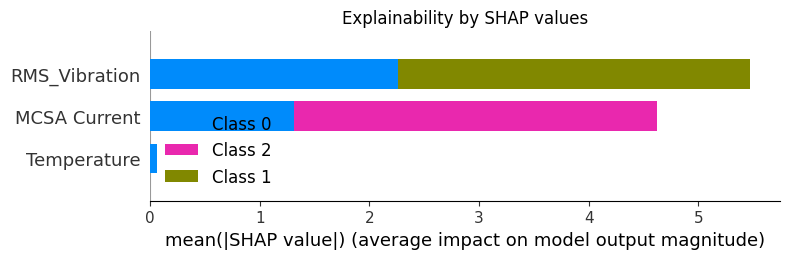

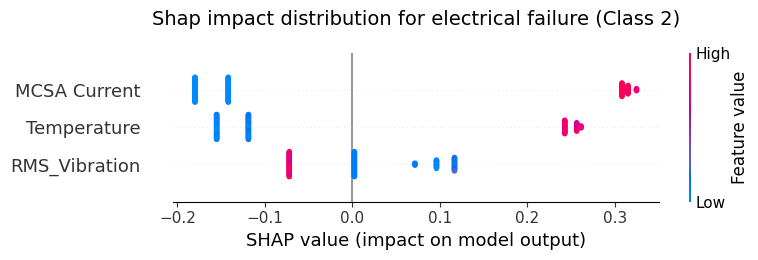

Indexes for Motor electrical failure in y_test:
[422, 461, 447, 580, 526]


/usr/local/lib/python3.12/dist-packages/shap/plots/_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


<Figure size 1200x400 with 0 Axes>

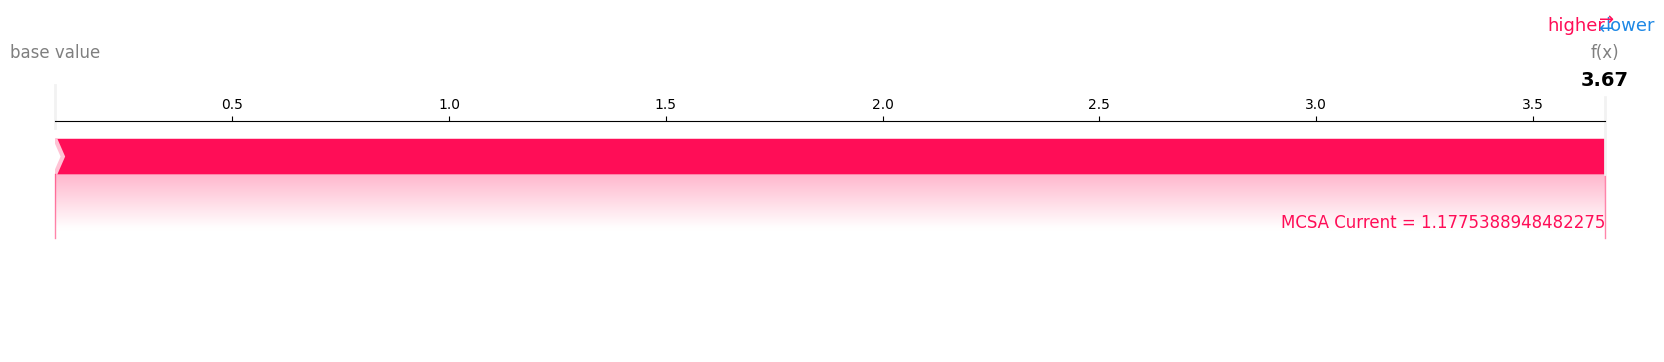

In [76]:
#Shap Explanation for XGBoost Model
shap_explainer_xgb=shap.TreeExplainer(model_xgb)
shap_values_xgb=shap_explainer_xgb.shap_values(X_test)
plt.figure(figsize=(6,4))
plt.title("Explainability by SHAP values")
shap.summary_plot(shap_values_xgb,X_test,plot_type="bar",show=False)
plt.tight_layout()
plt.show()

#SHAP Beeswarm Plot

obj_electricxgb_explainer = shap.Explanation(
    values=shap_values[:, :, 2],
    data=X_test,
    feature_names=X_test.columns
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(obj_electricxgb_explainer, max_display=3, show=False)
plt.title("Shap impact distribution for electrical failure (Class 2)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


#SHAP Force Plot

#Index searching for an electric failure case
index_electric_fail = y_test[y_test == 2].index
print("Indexes for Motor electrical failure in y_test:")
print(list(index_electric_fail)[:5])



shap.initjs()


chosen_index = index_electric_fail[1]

position_in_test = X_test.index.get_loc(chosen_index)

obj_Ele_fail_xgb = shap.Explanation(
    values=shap_values_xgb[position_in_test, :, 2],
    base_values=shap_explainer_xgb.expected_value[2],
    data=X_test.iloc[position_in_test],
    feature_names=X_test.columns
)

# Force Plot Creation
plt.figure(figsize=(12, 4))
shap.plots.force(obj_Ele_fail_xgb, matplotlib=True)

Implementing Support Vector Machine (SVM) is useful to test a geometric approach for our dataset. SVM works by finding a hyperplane that maximizes the margin between the different motor states (Healthy, Mechanical Failure, and Electrical Failure). Since our synthetic data is based on strict operational thresholds, this model is expected to perform very well in separating the boundaries lineally.

--- MODEL PERFORMANCE METRICS (SVM) ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        40
         1.0       1.00      1.00      1.00        40
         2.0       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



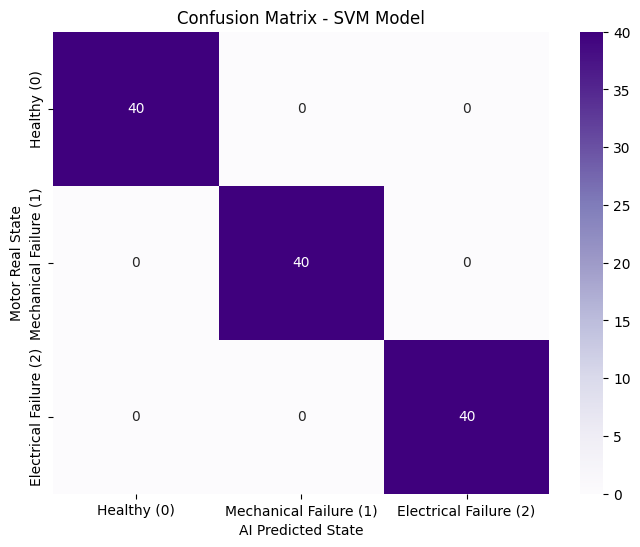

In [77]:
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)
print("--- MODEL PERFORMANCE METRICS (SVM) ---")
print(classification_report(y_test, svm_predictions))
matrix_svm = confusion_matrix(y_test, svm_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_svm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=["Healthy (0)", "Mechanical Failure (1)", "Electrical Failure (2)"],
    yticklabels=["Healthy (0)", "Mechanical Failure (1)", "Electrical Failure (2)"]
)
plt.title("Confusion Matrix - SVM Model")
plt.xlabel("AI Predicted State")
plt.ylabel("Motor Real State")
plt.show()

Finally, a soft voting classification model is implemented to correct any individual inaccuracies from the previous models. By combining Random Forest, XGBoost, and SVM, the ensemble averages the predicted probabilities of each class. This approach successfully eliminates the false negatives, ensuring a robust 100% accuracy and making the diagnostic system highly reliable for industrial motor monitoring.

--- MODEL PERFORMANCE METRICS (HYBRID ENSEMBLE) ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        40
         1.0       1.00      1.00      1.00        40
         2.0       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



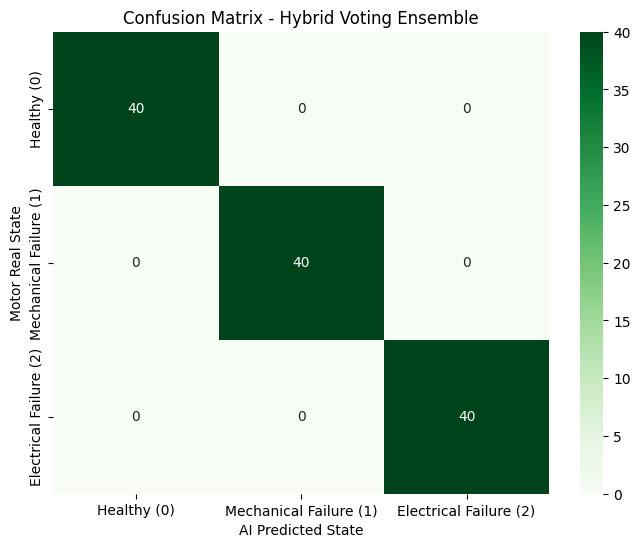

In [78]:

voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', model_xgb),
        ('svm', svm_model)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)
ensemble_predictions = voting_model.predict(X_test)
print("--- MODEL PERFORMANCE METRICS (HYBRID ENSEMBLE) ---")
print(classification_report(y_test, ensemble_predictions))
matrix_ensemble = confusion_matrix(y_test, ensemble_predictions)
plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix_ensemble,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["Healthy (0)", "Mechanical Failure (1)", "Electrical Failure (2)"],
    yticklabels=["Healthy (0)", "Mechanical Failure (1)", "Electrical Failure (2)"]
)

plt.title("Confusion Matrix - Hybrid Voting Ensemble")
plt.xlabel("AI Predicted State")
plt.ylabel("Motor Real State")
plt.show()

The Hybrid Voting Classifier achieved 100% accuracy, successfully resolving the classification error previously observed in the standalone XGBoost model. By implementing a soft voting strategy, the ensemble calculates the weighted average of the predicted probabilities from Random Forest, XGBoost, and SVM instead of relying on a single algorithm.

This hybrid architecture prevents false negatives—such as misclassifying a mechanical fault as a healthy motor—making the diagnostic system significantly more resilient and reliable for industrial condition monitoring applications.